# Evaluación 1 – Calidad y Preparación de Datos

**Integrantes:**
- Nombre 1 – correo1@duocuc.cl
- Nombre 2 – correo2@duocuc.cl
- Nombre 3 – correo3@duocuc.cl
- Nombre 4 – correo4@duocuc.cl

## 0. Carga de datos

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)

# URL del dataset
url = "https://raw.githubusercontent.com/chupetesuazo1/E1-EDA/refs/heads/main/rendimiento_academico_evaluacion.csv"
output_filename = "rendimiento_academico_evaluacion.csv"

# Descargar el dataset
!wget -O {output_filename} {url}

# Verificar que se haya descargado correctamente
if os.path.exists(output_filename):
    print(f"'{output_filename}' descargado exitosamente.")
else:
    print(f"Error al descargar '{output_filename}'.")

# Cargar el dataset
df = pd.read_csv(output_filename)

# Guardar una copia del dataset original
df_original = df.copy()

# Mostrar las primeras filas
df.head()

--2026-08-30 21:48:35--  https://raw.githubusercontent.com/chupetesuazo1/E1-EDA/refs/heads/main/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.1s    

2026-08-30 21:48:35 (3.44 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]

'rendimiento_academico_evaluacion.csv' descargado exitosamente.


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


## 1. Diagnóstico de calidad de datos

### 1.1 Caracterización del dataset (4 pts)

In [ ]:
print("Registros:", df.shape[0])
print("Variables:", df.shape[1])
print()
print(df.dtypes)
print()

# TODO: separar según lo que observen en dtypes / nombres de columna
variables_numericas = df.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numéricas:", variables_numericas)
print("Categóricas:", variables_categoricas)

Registros: 5100
Variables: 11

StudentID                object
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship              object
Program                  object
FinalGrade              float64
dtype: object

Numéricas: ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade']
Categóricas: ['StudentID', 'Scholarship', 'Program']


### Identificador y variable de resultado académico

Guiándonos por los nombres, la variable que corresponde al identificador y la variable que corresponde al resultado académico son StudentID y FinalGrade, pero para estar seguros, las estudiaremos a continuación:


In [ ]:
# Evidencia para identificar cada rol

# Candidata a identificador: columna tipo texto con formato de código
print("Candidata a identificador: 'StudentID'")
print(" - Tipo de dato:", df['StudentID'].dtype)
print(" - Registros totales:", len(df))
print(" - Valores únicos:", df['StudentID'].nunique())
print(" - ¿Es único en todo el dataset?:", df['StudentID'].is_unique)
print()

# Candidata a resultado académico: columna numérica que mide desempeño final
print("Candidata a resultado académico: 'FinalGrade'")
print(" - Tipo de dato:", df['FinalGrade'].dtype)
print(df['FinalGrade'].describe())

Candidata a identificador: 'StudentID'
 - Tipo de dato: object
 - Registros totales: 5100
 - Valores únicos: 5000
 - ¿Es único en todo el dataset?: False

Candidata a resultado académico: 'FinalGrade'
 - Tipo de dato: float64
count    5100.000000
mean        4.169539
std         0.993899
min        -1.459832
25%         3.510000
50%         4.230000
75%         4.860000
max         8.007300
Name: FinalGrade, dtype: float64


**Conclusión:**

Confirmamos entonces que `StudentID` es el identificador: es un código alfanumérico que no mide ninguna característica del estudiante, solo lo distingue de los demás registros. notamos que hay solo 5.000 valores únicos en 5.100 filas, es decir, hay IDs repetidos — no deja de ser el identificador

Y `FinalGrade` efectivamente es la variable de resultado académico: es la nota final del estudiante, numérica y continua, y es la que buscaríamos explicar/predecir a partir del resto (StudyHours, Attendance, PreviousGPA, etc.).

In [ ]:
print("="*60)
print("1.1 CARACTERIZACIÓN DEL DATASET")
print("="*60)
print(f"Cantidad de registros            : {df.shape[0]}")
print(f"Cantidad de variables             : {df.shape[1]}")
print()
print("Tipos de datos por variable:")
print(df.dtypes.to_string())
print()
print(f"Variables numéricas ({len(variables_numericas)})   :", variables_numericas)
print(f"Variables categóricas ({len(variables_categoricas)}) :", variables_categoricas)
print()
print("Variable identificador           :", "StudentID")
print("Variable de resultado académico  :", "FinalGrade")

1.1 CARACTERIZACIÓN DEL DATASET
Cantidad de registros            : 5100
Cantidad de variables             : 11

Tipos de datos por variable:
StudentID                object
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship              object
Program                  object
FinalGrade              float64

Variables numéricas (8)   : ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade']
Variables categóricas (3) : ['StudentID', 'Scholarship', 'Program']

Variable identificador           : StudentID
Variable de resultado académico  : FinalGrade


### 1.2 Valores faltantes (5 pts)

A continuación veremos la cantidad de valores faltantes y el porcentaje que representan del dataset

In [ ]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({"n_faltantes": faltantes, "%_faltantes": porcentaje})
resumen_faltantes = resumen_faltantes[resumen_faltantes["n_faltantes"] > 0].sort_values("%_faltantes", ascending=False)
resumen_faltantes

,n_faltantes,%_faltantes
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37


Ordenados de mayor a menor por porcentaje de daltantes tendriamos:

In [ ]:
print("="*60)
print("VARIABLE(S) CON MAYOR CANTIDAD DE DATOS FALTANTES")
print("="*60)

peor_var = resumen_faltantes.index[0]
print(f"-> '{peor_var}' es la variable con más datos faltantes: "
      f"{int(resumen_faltantes.loc[peor_var, 'n_faltantes'])} valores "
      f"({resumen_faltantes.loc[peor_var, '%_faltantes']}% del total de registros)")
print()
print("Ranking completo (de mayor a menor % de faltantes):")
for var, row in resumen_faltantes.iterrows():
    print(f"  {var:<22} {int(row['n_faltantes']):>4} faltantes  ({row['%_faltantes']}%)")

VARIABLE(S) CON MAYOR CANTIDAD DE DATOS FALTANTES
-> 'Attendance' es la variable con más datos faltantes: 224 valores (4.39% del total de registros)

Ranking completo (de mayor a menor % de faltantes):
  Attendance              224 faltantes  (4.39%)
  AssignmentsCompleted    216 faltantes  (4.24%)
  StudyHours              181 faltantes  (3.55%)
  InternetHours           176 faltantes  (3.45%)
  PreviousGPA             162 faltantes  (3.18%)
  SleepHours              122 faltantes  (2.39%)
  Age                     103 faltantes  (2.02%)
  Scholarship              81 faltantes  (1.59%)
  Program                  70 faltantes  (1.37%)


## Estrategia de tratamiento

Para decidir cómo imputar cada variable con datos faltantes usamos dos reglas:

- **Variables cualitativas (categóricas):** se usa con la **moda**
- **Variables cuantitativas (numéricas):** se elige entre **media** y **mediana** según si la distribución presenta o no un *"efecto Bill Gates"*

para cada variable cuantitativa revisamos:
- **Asimetría (skewness):** |skew| > 1 para saber si la distribucion es asimetrica
- **% de outliers (regla IQR):** valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR]; más de 1% se considerara relevante.
- **Diferencia % entre media y mediana:** si es mayor a 2%, la media se está "corriendo" por los valores extremos.

Si se cumple al menos una de estas tres condiciones, tratamos la variable como asimétrica/con outliers relevantes, con lo que usaremos la mediana en lugar de la media


##Variables Cuantitativas

A continuación presentamos la estrategia que se usara sobre las variables cuantitativas, después de revisar las tres condiciones definidas anteriormente

In [ ]:
from scipy import stats as scipy_stats

num_con_na = [c for c in resumen_faltantes.index if c in variables_numericas]

filas = []
for col in num_con_na:
    s = df[col].dropna()
    media, mediana = s.mean(), s.median()
    skew = scipy_stats.skew(s)
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    pct_out = round(n_out / len(s) * 100, 2)
    dif_pct = round(abs(media - mediana) / mediana * 100, 2)

    hay_bill_gates = (abs(skew) > 1) or (pct_out > 1) or (dif_pct > 2)
    estrategia = "Mediana" if hay_bill_gates else "Media"

    filas.append([col, int(resumen_faltantes.loc[col, "n_faltantes"]), resumen_faltantes.loc[col, "%_faltantes"],
                  round(media, 2), round(mediana, 2), round(skew, 2), pct_out, dif_pct,
                  "Sí" if hay_bill_gates else "No", estrategia])

tabla_num = pd.DataFrame(filas, columns=[
    "Variable", "n_faltantes", "%_faltantes", "Media", "Mediana",
    "Asimetría (skew)", "%_outliers (IQR)", "Dif. media-mediana (%)",
    "¿Efecto Bill Gates?", "Estrategia de imputación"
]).sort_values("%_faltantes", ascending=False).reset_index(drop=True)

tabla_num

,Variable,n_faltantes,%_faltantes,Media,Mediana,Asimetría (skew),%_outliers (IQR),Dif. media-mediana (%),¿Efecto Bill Gates?,Estrategia de imputación
0,Attendance,224,4.39,84.66,85.49,-1.34,0.55,0.97,Sí,Mediana
1,AssignmentsCompleted,216,4.24,85.21,87.76,-0.84,0.35,2.90,Sí,Mediana
2,StudyHours,181,3.55,12.43,12.01,4.68,1.00,3.46,Sí,Mediana
3,InternetHours,176,3.45,6.68,5.82,5.41,2.94,14.70,Sí,Mediana
4,PreviousGPA,162,3.18,5.71,5.72,-0.24,0.43,0.26,No,Media
5,SleepHours,122,2.39,6.99,7.03,-1.24,0.68,0.57,Sí,Mediana
6,Age,103,2.02,23.80,23.00,3.30,1.26,3.47,Sí,Mediana


Para ilustar mejor la diferencia entre usar la media y mediana en cada caso presentamos los siguientes graficos, donde podremos ver donde se encuentra la media y mediana

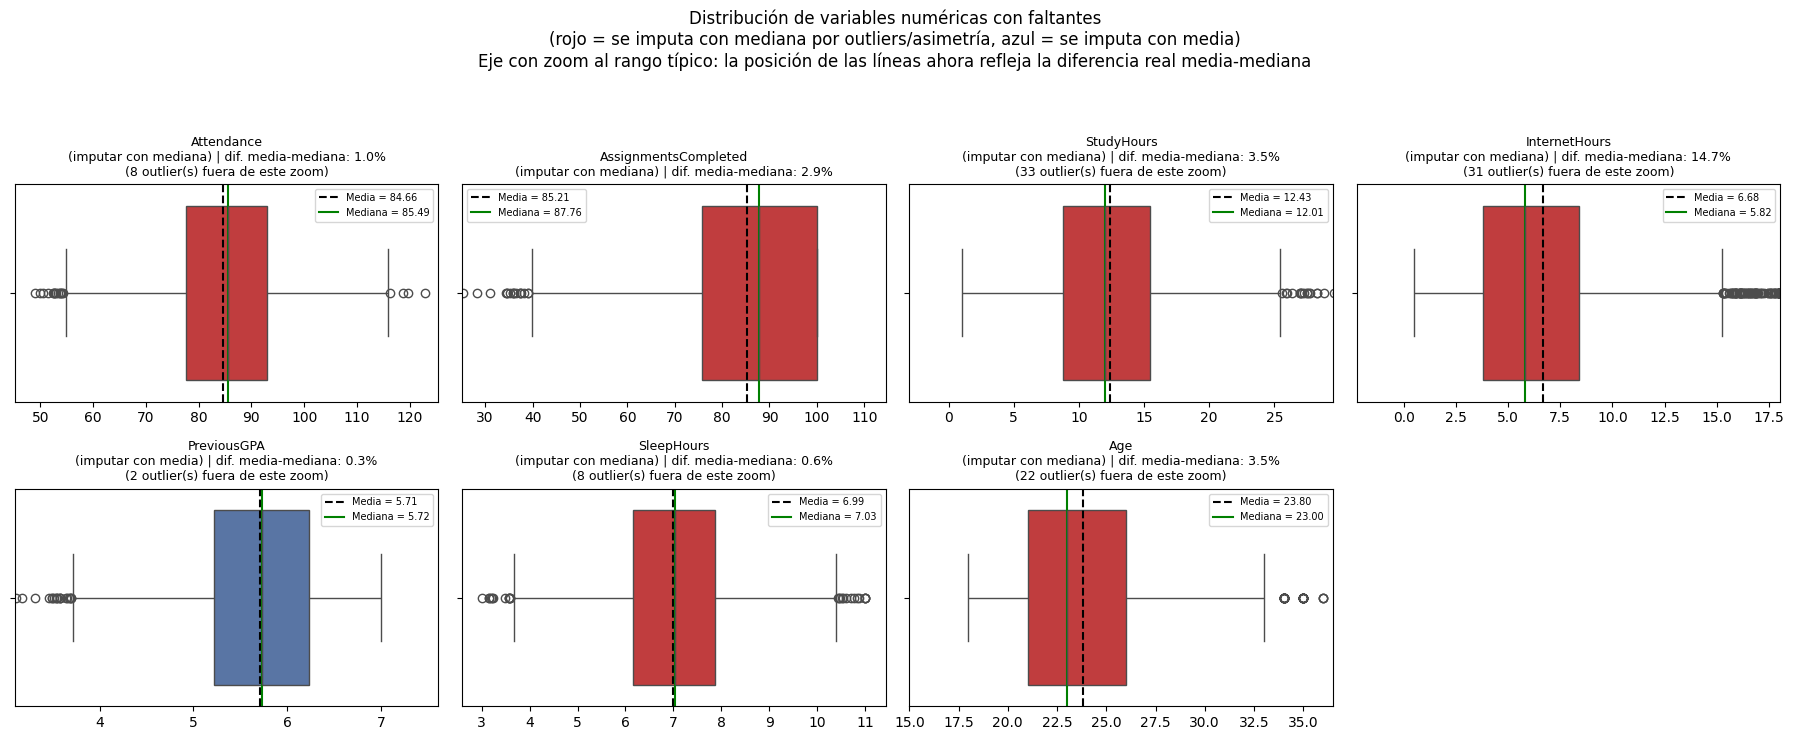

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_con_na):
    ax = axes[i]
    s = df[col].dropna()
    fila = tabla_num.loc[tabla_num["Variable"] == col].iloc[0]
    estrategia = fila["Estrategia de imputación"]
    dif_pct = fila["Dif. media-mediana (%)"]
    color = "#d62728" if estrategia == "Mediana" else "#4C72B0"

    media, mediana = s.mean(), s.median()

    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    margen = (lim_sup - lim_inf) * 0.15
    xlim_low = max(s.min(), lim_inf) - margen
    xlim_high = min(s.max(), lim_sup) + margen
    n_fuera = int(((s < xlim_low) | (s > xlim_high)).sum())

    sns.boxplot(x=s, ax=ax, color=color)
    ax.axvline(media, color="black", linestyle="--", linewidth=1.5, label=f"Media = {media:.2f}")
    ax.axvline(mediana, color="green", linestyle="-", linewidth=1.5, label=f"Mediana = {mediana:.2f}")
    ax.set_xlim(xlim_low, xlim_high)

    titulo = f"{col}\n(imputar con {estrategia.lower()}) | dif. media-mediana: {dif_pct:.1f}%"
    if n_fuera > 0:
        titulo += f"\n({n_fuera} outlier(s) fuera de este zoom)"
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)

for j in range(len(num_con_na), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de variables numéricas con faltantes\n(rojo = se imputa con mediana por outliers/asimetría, azul = se imputa con media)\nEje con zoom al rango típico: la posición de las líneas ahora refleja la diferencia real media-mediana", y=1.05)
plt.tight_layout()
plt.show()

##Variables Cualitativas

A continuacion presentamos la estrategia que se usara sobre las variables cualitativas, despues de revisar las tres condiciones definidas anteriormente

In [ ]:
cat_con_na = [c for c in resumen_faltantes.index if c in variables_categoricas]

filas = []
for col in cat_con_na:
    vc = df[col].value_counts(dropna=True)
    moda = vc.idxmax()
    pct_moda = round(vc.max() / vc.sum() * 100, 2)
    filas.append([col, int(resumen_faltantes.loc[col, "n_faltantes"]), resumen_faltantes.loc[col, "%_faltantes"],
                  moda, pct_moda, "Moda"])

tabla_cat = pd.DataFrame(filas, columns=[
    "Variable", "n_faltantes", "%_faltantes", "Moda", "% que representa la moda", "Estrategia de imputación"
]).sort_values("%_faltantes", ascending=False).reset_index(drop=True)

tabla_cat

,Variable,n_faltantes,%_faltantes,Moda,% que representa la moda,Estrategia de imputación
0,Scholarship,81,1.59,No,67.03,Moda
1,Program,70,1.37,Ingeniería Informática,28.31,Moda


En este grafico podemos ver los distintos valores que puede tomar cada variable, así como ilustrar mejor que tanto representa la moda

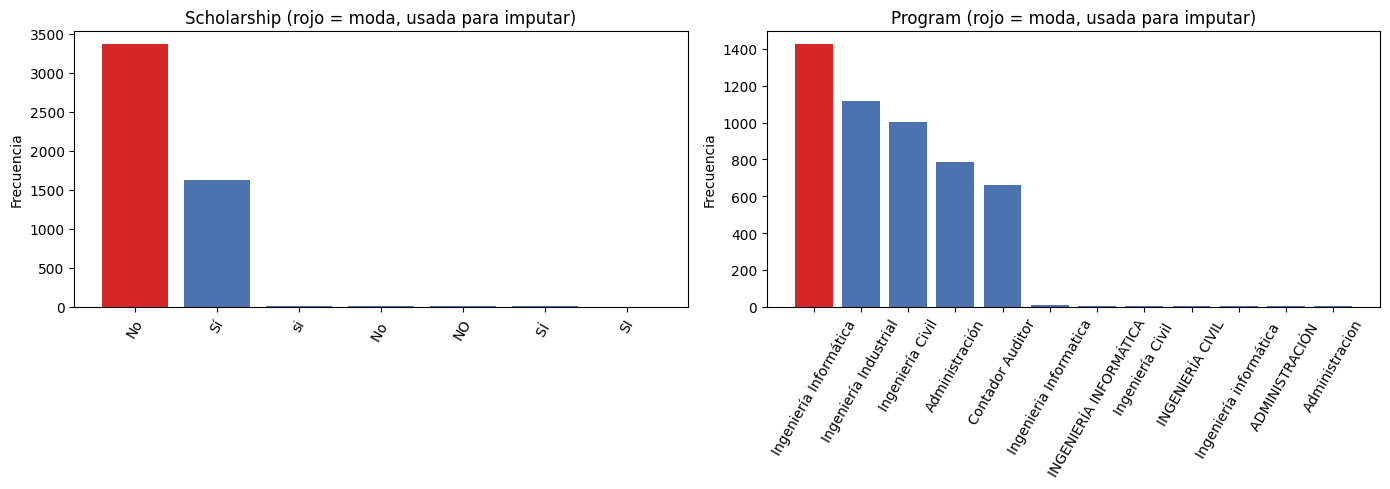

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_con_na):
    vc = df[col].value_counts(dropna=True)
    colors = ["#d62728" if idx == vc.idxmax() else "#4C72B0" for idx in vc.index]
    ax.bar(vc.index.astype(str), vc.values, color=colors)
    ax.set_title(f"{col} (rojo = moda, usada para imputar)")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## 1.3 Registros duplicados (4 pts)

A continuación presentamos la cantidad de registros duplicados asi como su porcentaje con respecto al dataset

In [ ]:
print("="*60)
print("1.3 REGISTROS DUPLICADOS")
print("="*60)

n_duplicados = df.duplicated().sum()
pct_duplicados = round(n_duplicados / len(df) * 100, 2)

print(f"Registros duplicados (fila completa idéntica) : {n_duplicados}")
print(f"Porcentaje respecto del dataset                : {pct_duplicados}%")

1.3 REGISTROS DUPLICADOS
Registros duplicados (fila completa idéntica) : 100
Porcentaje respecto del dataset                : 1.96%


Como ya sabemos del punto 1.1, los 100 valores repetidos corresponderán un id repetido, para tomar una decisión, veremos si solo se repite el id, o el registro completo esta repetido:    

In [ ]:
dup_id = df.duplicated(subset="StudentID", keep=False)
dup_fila = df.duplicated(keep=False)

print("Filas con StudentID repetido      :", dup_id.sum())
print("Filas con fila completa repetida  :", dup_fila.sum())
print("¿Coinciden exactamente?           :", (dup_id == dup_fila).all())

# ¿hay algún StudentID repetido donde el resto de columnas NO coincide?
otras_cols = [c for c in df.columns if c != "StudentID"]
inconsistentes = (df[dup_id].groupby("StudentID")[otras_cols].nunique() > 1).any(axis=1).sum()
print("StudentID repetidos con datos distintos en el resto de columnas:", inconsistentes)

Filas con StudentID repetido      : 200
Filas con fila completa repetida  : 200
¿Coinciden exactamente?           : True
StudentID repetidos con datos distintos en el resto de columnas: 0


##Tratamiento Duplicados

Al ser 100 registros duplicados, donde todos sus campos iguales (copias exactas de otro registro), estos seran descartados dado que podrian sesgar un modelo posterior, ademas de no aportar informacion nueva y representar una parte pequeña del dataset (1.96%)

##1.4 Inconsistencias

Para detectar inconsistencias revisamos, para cada variable, el dominio de valores válidos según su significado:

- **Attendance**: porcentaje de asistencia → debe estar en `[0, 100]`
- **SleepHours** / **InternetHours** / **StudyHours**: horas dentro de un día → deben estar en `[0, 24]`
- **FinalGrade**: → debe estar en `[1.0, 7.0]`
- **PreviousGPA**: promedio anterior, misma escala `[1.0, 7.0]`
- **AssignmentsCompleted**: porcentaje de tareas completadas → `[0, 100]`
- **Scholarship** / **Program**: variables categóricas → deben tener un conjunto fijo y estandarizado de categorías
- **Age**: no tiene un límite matemático estricto, revisamos que no hayan valores extraños (como valores negativos)

A continuación presentamos una tabla para las variables cuantitativas que nos mostrara si existen inconsistencias que no respeten estas normas


In [ ]:
print("="*60)
print("1.4 INCONSISTENCIAS - VARIABLES NUMÉRICAS (fuera de dominio)")
print("="*60)

# Dominio válido de cada variable según su significado
dominios = {
    "Age":           (0, 100),    # edad de una persona
    "Attendance":    (0, 100),    # % de asistencia
    "AssignmentsCompleted": (0, 100), # % de tareas completadas
    "PreviousGPA":   (1.0, 7.0),  # escala de notas chilena
    "SleepHours":    (0, 24),     # horas de sueño en un día
    "InternetHours": (0, 24),     # horas de uso de internet en un día
    "StudyHours":    (0, 24),     # horas de estudio en un día
    "FinalGrade":    (1.0, 7.0),  # escala de notas chilena
}

filas = []
for col, (lo, hi) in dominios.items():
    s = df[col].dropna()
    n_bajo = int((s < lo).sum())
    n_alto = int((s > hi).sum())
    n_total = n_bajo + n_alto
    pct = round(n_total / len(df) * 100, 2)
    filas.append([col, f"[{lo}, {hi}]", round(s.min(), 2), round(s.max(), 2),
                  n_bajo, n_alto, n_total, pct])

tabla_dominio = pd.DataFrame(filas, columns=[
    "Variable", "Dominio válido", "Mín. observado", "Máx. observado",
    "n_bajo_dominio", "n_sobre_dominio", "n_inconsistentes", "%_inconsistentes"
]).sort_values("n_inconsistentes", ascending=False).reset_index(drop=True)

tabla_dominio

1.4 INCONSISTENCIAS - VARIABLES NUMÉRICAS (fuera de dominio)


,Variable,Dominio válido,Mín. observado,Máx. observado,n_bajo_dominio,n_sobre_dominio,n_inconsistentes,%_inconsistentes
0,StudyHours,"[0, 24]",1.00,98.33,0,69,69,1.35
1,InternetHours,"[0, 24]",0.50,69.50,0,31,31,0.61
2,Attendance,"[0, 100]",-19.96,122.97,8,12,20,0.39
3,FinalGrade,"[1.0, 7.0]",-1.46,8.01,4,6,10,0.20
4,SleepHours,"[0, 24]",-7.71,11.00,8,0,8,0.16
5,PreviousGPA,"[1.0, 7.0]",2.95,7.00,0,0,0,0.00
6,Age,"[0, 100]",18.00,80.00,0,0,0,0.00
7,AssignmentsCompleted,"[0, 100]",25.34,100.00,0,0,0,0.00


De la misma forma, presentamos una tabla que permite identificar si en las variables cualitativas existen registros inconsistentes, diferenciando entre variantes de formato, donde es posible reconocer el valor que representan, e inconsistencias en las que no es posible determinar a qué valor corresponden.

In [ ]:
import unicodedata

def normalizar(texto):
    """Quita espacios, mayúsculas y tildes para comparar variantes de un mismo valor."""
    if pd.isna(texto):
        return texto
    t = texto.strip()
    t = ''.join(c for c in unicodedata.normalize('NFD', t) if unicodedata.category(c) != 'Mn')
    return t.lower()

# Categorías oficiales válidas para cada variable (el dominio real, no solo lo que aparece en el df)
categorias_oficiales = {
    "Scholarship": {"si": "Sí", "no": "No"},
    "Program": {
        "ingenieria informatica": "Ingeniería Informática",
        "ingenieria industrial": "Ingeniería Industrial",
        "ingenieria civil": "Ingeniería Civil",
        "administracion": "Administración",
        "contador auditor": "Contador Auditor",
    },
}

print("="*60)
print("1.4 INCONSISTENCIAS - VARIABLES CATEGÓRICAS (formato no estandarizado)")
print("="*60)

filas_cat = []
for col, oficiales in categorias_oficiales.items():
    print(f"\n--- {col} ---")
    variantes_por_categoria = {}
    no_reconocidos = {}

    for val in df[col].dropna().unique():
        key = normalizar(val)
        n_val = int((df[col] == val).sum())
        if key in oficiales:
            categoria = oficiales[key]
            if val != categoria:
                # mismo significado, pero escrito distinto (mayúsculas/tildes/espacios)
                variantes_por_categoria.setdefault(categoria, {})[val] = n_val
        else:
            # no calza con ninguna categoría conocida, ni siquiera como variante de formato
            no_reconocidos[val] = n_val

    for categoria, variantes in variantes_por_categoria.items():
        n_principal = int((df[col] == categoria).sum())
        n_otras = sum(variantes.values())
        print(f"  Categoría real: '{categoria}' ({n_principal} registros)")
        print(f"    Variantes de formato: {variantes}  -> {n_otras} registros a corregir")
        filas_cat.append([col, categoria, "Variante de formato", str(variantes), n_otras])

    if no_reconocidos:
        n_otras = sum(no_reconocidos.values())
        print(f"  Valores NO reconocidos (no calzan con ninguna categoría del dominio): {no_reconocidos}  -> {n_otras} registros")
        filas_cat.append([col, "N/A", "Valor no reconocido / posible error de captura", str(no_reconocidos), n_otras])
    else:
        print("  Sin valores ajenos al dominio: todo lo que no es la forma oficial es solo un problema de formato.")

tabla_cat_inconsist = pd.DataFrame(filas_cat, columns=[
    "Variable", "Categoría estándar", "Tipo de problema", "Valores detectados", "n_inconsistentes"
])
tabla_cat_inconsist

1.4 INCONSISTENCIAS - VARIABLES CATEGÓRICAS (formato no estandarizado)

--- Scholarship ---
  Categoría real: 'No' (3364 registros)
    Variantes de formato: {'NO': 8, 'No ': 10}  -> 18 registros a corregir
  Categoría real: 'Sí' (1620 registros)
    Variantes de formato: {'si': 10, 'SI': 2, 'SÍ ': 5}  -> 17 registros a corregir
  Sin valores ajenos al dominio: todo lo que no es la forma oficial es solo un problema de formato.

--- Program ---
  Categoría real: 'Ingeniería Informática' (1424 registros)
    Variantes de formato: {'INGENIERÍA INFORMÁTICA': 7, 'Ingeniería informática ': 4, 'Ingenieria Informatica': 10}  -> 21 registros a corregir
  Categoría real: 'Administración' (787 registros)
    Variantes de formato: {'ADMINISTRACIÓN ': 3, 'Administracion': 3}  -> 6 registros a corregir
  Categoría real: 'Ingeniería Civil' (1004 registros)
    Variantes de formato: {'Ingeniería Civil ': 5, 'INGENIERÍA CIVIL': 4}  -> 9 registros a corregir
  Sin valores ajenos al dominio: todo lo que 

,Variable,Categoría estándar,Tipo de problema,Valores detectados,n_inconsistentes
0,Scholarship,No,Variante de formato,"{'NO': 8, 'No ': 10}",18
1,Scholarship,Sí,Variante de formato,"{'si': 10, 'SI': 2, 'SÍ ': 5}",17
2,Program,Ingeniería Informática,Variante de formato,"{'INGENIERÍA INFORMÁTICA': 7, 'Ingeniería info...",21
3,Program,Administración,Variante de formato,"{'ADMINISTRACIÓN ': 3, 'Administracion': 3}",6
4,Program,Ingeniería Civil,Variante de formato,"{'Ingeniería Civil ': 5, 'INGENIERÍA CIVIL': 4}",9


##Tratamiento Inconsistencias
###Cualitativas

Las variables cualitativas presentan únicamente errores de sintaxis. Dado que no existen registros cuyos valores no puedan ser identificados o interpretados, se optará por estandarizarlos con el objetivo de mantener un formato consistente en el dataset.
###Cuantitativas

En cuanto a las variables cuantitativas, las inconsistencias identificadas serán tratadas como valores faltantes, utilizando la media o la mediana según lo obtenido en el punto 1.2. Además, estas inconsistencias representan un porcentaje muy bajo del dataset.

Para el caso particular de la variable SleepHours, se podría aplicar la función abs() a los valores negativos, ya que, al convertirlos a positivos, dejarían de ser inconsistentes. Además, la mayoría de estos valores presentan magnitudes similares a otros ya existentes en el dataset, con excepción de algunos que podrían considerarse atípicos.

Sin embargo, aunque estos valores positivos son posibles, existe incertidumbre respecto de si fueron ingresados incorrectamente como negativos o si efectivamente representan valores válidos. Por este motivo, se decidió aplicar el mismo tratamiento que al resto de las variables cuantitativas y tratarlos como valores faltantes, reemplazándolos según lo establecido en el punto 1.2.

A continuación presentamos los valores atipicos de SleepHours y como quedarian al aplicar el abs()

In [ ]:
lo, hi = dominios["SleepHours"]

# valores válidos observados (para comparar contra ellos)
validos = df["SleepHours"][(df["SleepHours"] >= lo) & (df["SleepHours"] <= hi)]

# anómalos + su valor absoluto
anomalos = df.loc[(df["SleepHours"] < lo) | (df["SleepHours"] > hi), ["StudentID", "SleepHours"]].copy()
anomalos["valor_abs"] = anomalos["SleepHours"].abs()

print(f"Rango de SleepHours válidos observados: [{validos.min():.2f}, {validos.max():.2f}]")
print(f"Media: {validos.mean():.2f}  |  Mediana: {validos.median():.2f}  |  Std: {validos.std():.2f}\n")

# ¿el valor absoluto cae dentro del rango que realmente se observa en los datos válidos?
anomalos["parecido_a_validos"] = anomalos["valor_abs"].between(validos.min(), validos.max())

print(anomalos.sort_values("SleepHours").to_string(index=False))

n_parecidos = anomalos["parecido_a_validos"].sum()
n_total_anomalos = len(anomalos)

print(f"\nAnómalos cuyo valor absoluto cae dentro del rango observado: {n_parecidos}/{n_total_anomalos}")
print(f"% sobre el total de anómalos de SleepHours : {n_parecidos/n_total_anomalos*100:.1f}%")
print(f"% sobre el total del dataset                : {n_parecidos/len(df)*100:.2f}%")

Rango de SleepHours válidos observados: [3.00, 11.00]
Media: 7.01  |  Mediana: 7.03  |  Std: 1.24

StudentID  SleepHours  valor_abs  parecido_a_validos
STU-14004   -7.713498   7.713498                True
STU-12862   -6.725603   6.725603                True
STU-10904   -6.384765   6.384765                True
STU-14243   -5.680878   5.680878                True
STU-10970   -5.275488   5.275488                True
STU-12580   -4.617317   4.617317                True
STU-14711   -1.897606   1.897606               False
STU-11068   -1.391069   1.391069               False

Anómalos cuyo valor absoluto cae dentro del rango observado: 6/8
% sobre el total de anómalos de SleepHours : 75.0%
% sobre el total del dataset                : 0.12%


A continuación mostramos un resumen general de como se trataran a las variables

In [ ]:
import pandas as pd
from google.colab import data_table

# 1. Desactiva la tabla interactiva de Colab (la que corta el texto y no hace wrap)
data_table.disable_dataframe_formatter()

# 2. Evita que pandas trunque strings largos con "..."
pd.set_option('display.max_colwidth', None)

n = len(df)
resumen_inconsistencias = pd.DataFrame([
    ["Attendance", "Porcentaje de asistencia fuera de [0,100] (valores negativos y valores > 100%)",
     20, round(20/n*100, 2), "Reemplazar con Mediana"],
    ["SleepHours", "Horas de sueño negativas (imposible: dominio físico [0,24] h/día)",
     8, round(8/n*100, 2), "Reemplazar con Mediana"],
    ["InternetHours", "Horas de uso de internet > 24 en un mismo día (dominio físico [0,24])",
     31, round(31/n*100, 2), "Reemplazar con Mediana"],
    ["StudyHours", "Horas de estudio > 24 en un mismo día, asumiendo medición diaria (igual escala que SleepHours/InternetHours)",
     69, round(69/n*100, 2), "Reemplazar con Mediana"],
    ["FinalGrade", "Notas fuera de la escala de evaluación [1.0, 7.0]",
     10, round(10/n*100, 2), "Reemplazar con Mediana"],
    ["Scholarship", "Mismo valor escrito de formas distintas ('si', 'NO', 'SÍ ', etc.) en vez de solo 'Sí'/'No'",
     35, round(35/n*100, 2), "Estandarizar texto"],
    ["Program", "Mismo programa escrito de formas distintas (mayúsculas, tildes faltantes, espacios extra)",
     36, round(36/n*100, 2), "Estandarizar texto"],
], columns=["Variable", "Problema detectado", "Cantidad", "% del dataset", "Estrategia de tratamiento propuesta"])

resumen_inconsistencias

,Variable,Problema detectado,Cantidad,% del dataset,Estrategia de tratamiento propuesta
0,Attendance,"Porcentaje de asistencia fuera de [0,100] (valores negativos y valores > 100%)",20,0.39,Reemplazar con Mediana
1,SleepHours,"Horas de sueño negativas (imposible: dominio físico [0,24] h/día)",8,0.16,Reemplazar con Mediana
2,InternetHours,"Horas de uso de internet > 24 en un mismo día (dominio físico [0,24])",31,0.61,Reemplazar con Mediana
3,StudyHours,"Horas de estudio > 24 en un mismo día, asumiendo medición diaria (igual escala que SleepHours/InternetHours)",69,1.35,Reemplazar con Mediana
4,FinalGrade,"Notas fuera de la escala de evaluación [1.0, 7.0]",10,0.20,Reemplazar con Mediana
5,Scholarship,"Mismo valor escrito de formas distintas ('si', 'NO', 'SÍ ', etc.) en vez de solo 'Sí'/'No'",35,0.69,Estandarizar texto
6,Program,"Mismo programa escrito de formas distintas (mayúsculas, tildes faltantes, espacios extra)",36,0.71,Estandarizar texto


##1.5 Valores Atípicos

### Metodología

Para detectar valores atípicos en las 8 variables numéricas utilizamos el mismo criterio ya aplicado en el punto 1.2: la regla IQR (rango intercuartílico), donde se considera atípico todo valor fuera de $[Q_1 - 1.5\cdot IQR,\ Q_3 + 1.5\cdot IQR]$. Como respaldo adicional también calculamos el conteo de atípicos según el puntaje Z ($|Z|>3$) (sirve para medir qué tan lejos está un dato del promedio.), útil como verificación cruzada, sobre todo en las variables menos asimétricas (PreviousGPA, Attendance, AssignmentsCompleted).


In [ ]:
print("="*60)
print("1.5 VALORES ATÍPICOS - REGLA IQR (por variable)")
print("="*60)

filas = []
for col in variables_numericas:
    s = df[col].dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr

    es_outlier_iqr = (s < lim_inf) | (s > lim_sup)
    n_out_iqr = int(es_outlier_iqr.sum())
    pct_out_iqr = round(n_out_iqr / len(s) * 100, 2)

    # verificación adicional con puntaje Z
    z = (s - s.mean()) / s.std()
    n_out_z = int((z.abs() > 3).sum())

    # de los atípicos IQR, ¿cuáles violan además el dominio válido definido en 1.4?
    dom_lo, dom_hi = dominios[col]
    outliers_iqr = s[es_outlier_iqr]
    n_invalidos = int(((outliers_iqr < dom_lo) | (outliers_iqr > dom_hi)).sum())
    n_extremos = n_out_iqr - n_invalidos

    filas.append([col, round(s.min(), 2), round(s.max(), 2), round(stats.skew(s), 2),
                  round(lim_inf, 2), round(lim_sup, 2),
                  n_out_iqr, pct_out_iqr, n_out_z, n_extremos, n_invalidos])

tabla_atipicos = pd.DataFrame(filas, columns=[
    "Variable", "Mín.", "Máx.", "Skew",
    "Lím. inf. (IQR)", "Lím. sup. (IQR)",
    "n_atípicos (IQR)", "%_atípicos (IQR)", "n_atípicos (|Z|>3)",
    "n_extremos (válidos)", "n_inválidos (fuera dominio)"
]).sort_values("%_atípicos (IQR)", ascending=False).reset_index(drop=True)

tabla_atipicos

1.5 VALORES ATÍPICOS - REGLA IQR (por variable)


,Variable,Mín.,Máx.,Skew,Lím. inf. (IQR),Lím. sup. (IQR),n_atípicos (IQR),%_atípicos (IQR),n_atípicos (|Z|>3),n_extremos (válidos),n_inválidos (fuera dominio)
0,InternetHours,0.50,69.50,5.41,-3.09,15.28,145,2.94,31,114,31
1,Age,18.00,80.00,3.30,13.50,33.50,63,1.26,17,63,0
2,StudyHours,1.00,98.33,4.68,-1.28,25.48,49,1.00,30,0,49
3,FinalGrade,-1.46,8.01,-0.26,1.48,6.89,37,0.73,18,27,10
4,SleepHours,-7.71,11.00,-1.24,3.61,10.41,34,0.68,12,26,8
5,Attendance,-19.96,122.97,-1.34,54.43,116.16,27,0.55,14,15,12
6,PreviousGPA,2.95,7.00,-0.24,3.70,7.75,21,0.43,8,21,0
7,AssignmentsCompleted,25.34,100.00,-0.84,39.62,136.23,17,0.35,29,17,0



###REGLA IQR (por variable)


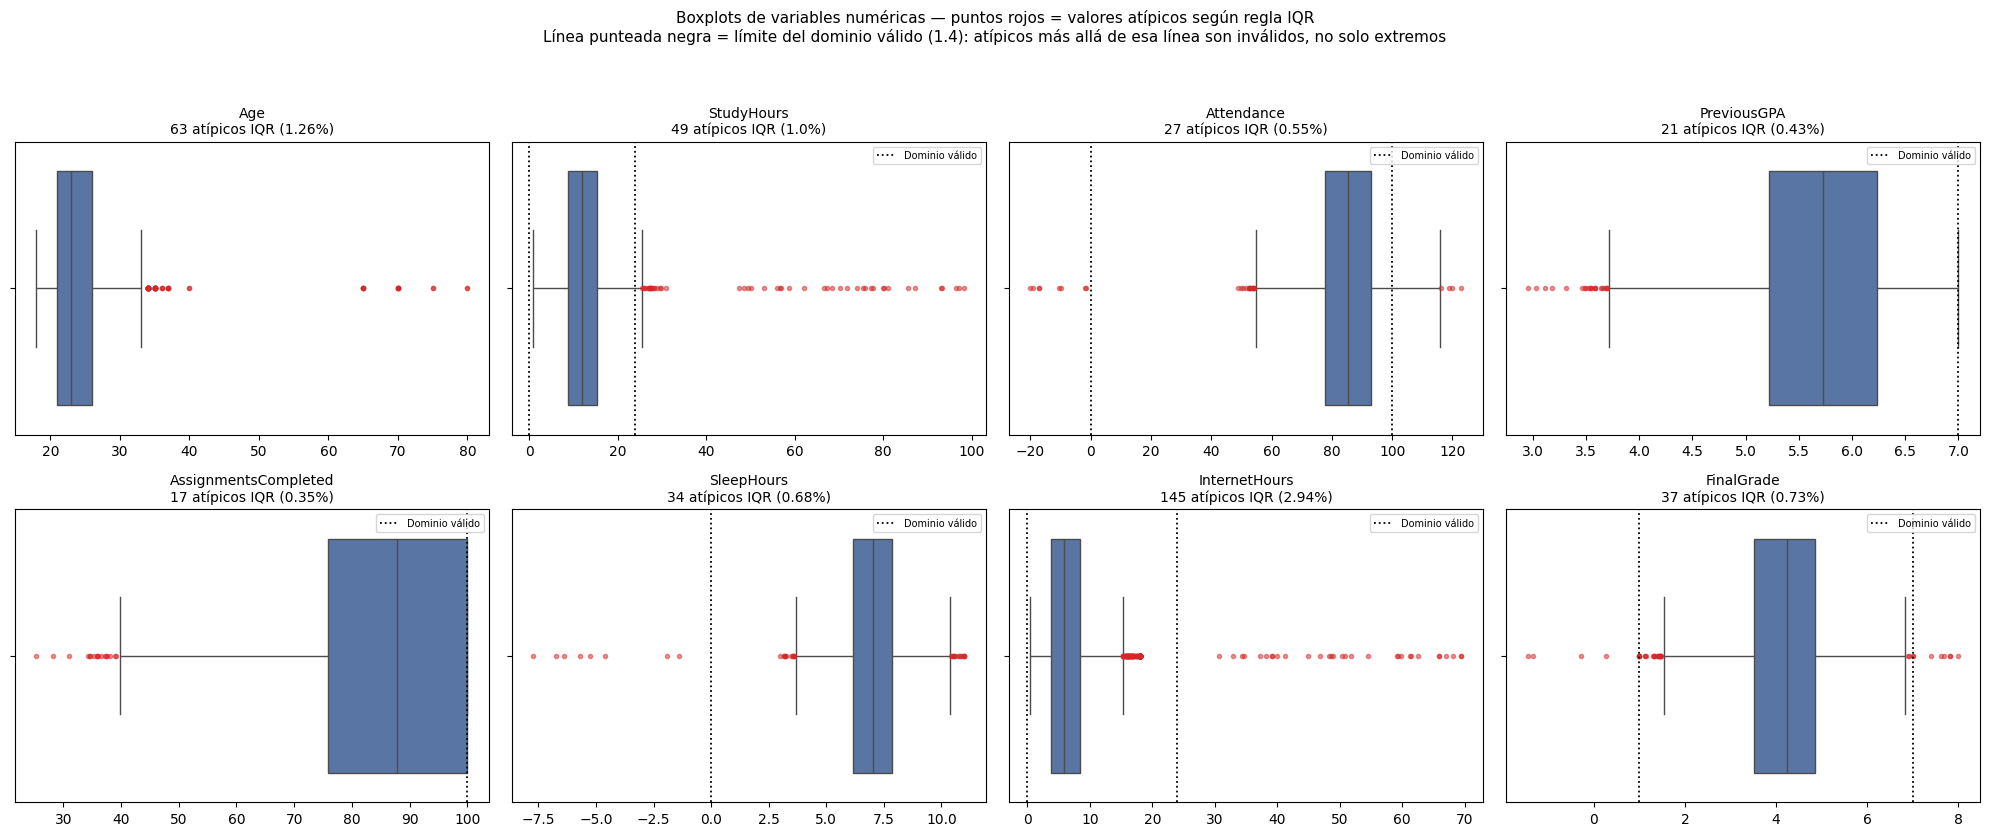

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    ax = axes[i]
    s = df[col].dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    dom_lo, dom_hi = dominios[col]

    sns.boxplot(x=s, ax=ax, color="#4C72B0", fliersize=3,
                flierprops=dict(marker='o', markerfacecolor='#d62728', markeredgecolor='#d62728', alpha=0.5))

    # línea de referencia con el límite del dominio válido (1.4), solo si está dentro del rango visible
    tiene_linea = False
    margen = (s.max() - s.min()) * 0.05
    if dom_lo > s.min() - margen:
        ax.axvline(dom_lo, color="black", linestyle=":", linewidth=1.3, label="Dominio válido")
        tiene_linea = True
    if dom_hi < s.max() + margen:
        ax.axvline(dom_hi, color="black", linestyle=":", linewidth=1.3, label="Dominio válido" if not tiene_linea else None)
        tiene_linea = True

    n_out = int(((s < lim_inf) | (s > lim_sup)).sum())
    pct_out = round(n_out/len(s)*100, 2)
    ax.set_title(f"{col}\n{n_out} atípicos IQR ({pct_out}%)", fontsize=10)
    ax.set_xlabel("")
    if tiene_linea:
        ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Boxplots de variables numéricas — puntos rojos = valores atípicos según regla IQR\n"
             "Línea punteada negra = límite del dominio válido (1.4): atípicos más allá de esa línea son inválidos, no solo extremos",
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
mask_out = pd.Series(False, index=df.index)
mask_inv = pd.Series(False, index=df.index)
mask_ext = pd.Series(False, index=df.index)

for col in variables_numericas:
    s = df[col]
    sv = s.dropna()
    q1, q3 = sv.quantile(.25), sv.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    es_out = ((s < lim_inf) | (s > lim_sup)).fillna(False)
    dom_lo, dom_hi = dominios[col]
    es_inv = ((s < dom_lo) | (s > dom_hi)).fillna(False)
    mask_out |= es_out
    mask_inv |= (es_out & es_inv)
    mask_ext |= (es_out & ~es_inv)

n = len(df)
print("="*60)
print("1.5 RESUMEN A NIVEL DE ESTUDIANTE (unión de las 8 variables numéricas)")
print("="*60)
print(f"Estudiantes con al menos 1 valor atípico (IQR)       : {mask_out.sum():4d}  ({mask_out.sum()/n*100:.2f}%)")
print(f"  - con al menos 1 valor inválido (fuera de dominio) : {mask_inv.sum():4d}  ({mask_inv.sum()/n*100:.2f}%)")
print(f"  - con al menos 1 valor extremo pero válido         : {mask_ext.sum():4d}  ({mask_ext.sum()/n*100:.2f}%)")
print(f"  - con ambos tipos a la vez                         : {(mask_inv & mask_ext).sum():4d}")

1.5 RESUMEN A NIVEL DE ESTUDIANTE (unión de las 8 variables numéricas)
Estudiantes con al menos 1 valor atípico (IQR)       :  372  (7.29%)
  - con al menos 1 valor inválido (fuera de dominio) :  108  (2.12%)
  - con al menos 1 valor extremo pero válido         :  270  (5.29%)
  - con ambos tipos a la vez                         :    6


### Resumen de tratamiento de valores atípicos e inválidos

Basado en el análisis anterior, se propone la siguiente estrategia para la fase de limpieza:

1.  **Valores Inválidos (Fuera de dominio):** En variables como `StudyHours`, `InternetHours`, `Attendance`, `FinalGrade` y `SleepHours`, los valores que exceden los límites lógicos o físicos serán tratados como valores faltantes (NaN) para luego ser imputados mediante la mediana o media segun corresponda (usando el diagnostico obtenido en el punto 1.2), dado que su presencia es baja pero distorsionan la realidad del dato.

2.  **Valores Extremos (Válidos):** En variables como `Age` o `PreviousGPA`, donde los valores son atípicos por la regla IQR pero aún así son posibles dentro del dominio humano/académico, se **mantendrán en el dataset**. Esto permite conservar la variabilidad natural de la población estudiantil, a menos que se demuestre que afectan negativamente el desempeño de modelos específicos más adelante.

# 2. Análisis exploratorio de datos

### 2.1 Distribución de Variables Numéricas (Incluyendo Atípicos e Inconsistencias)

Visualizamos las distribuciones originales para observar cómo los valores extremos e inconsistentes detectados en el diagnóstico afectan la forma y escala de los datos.

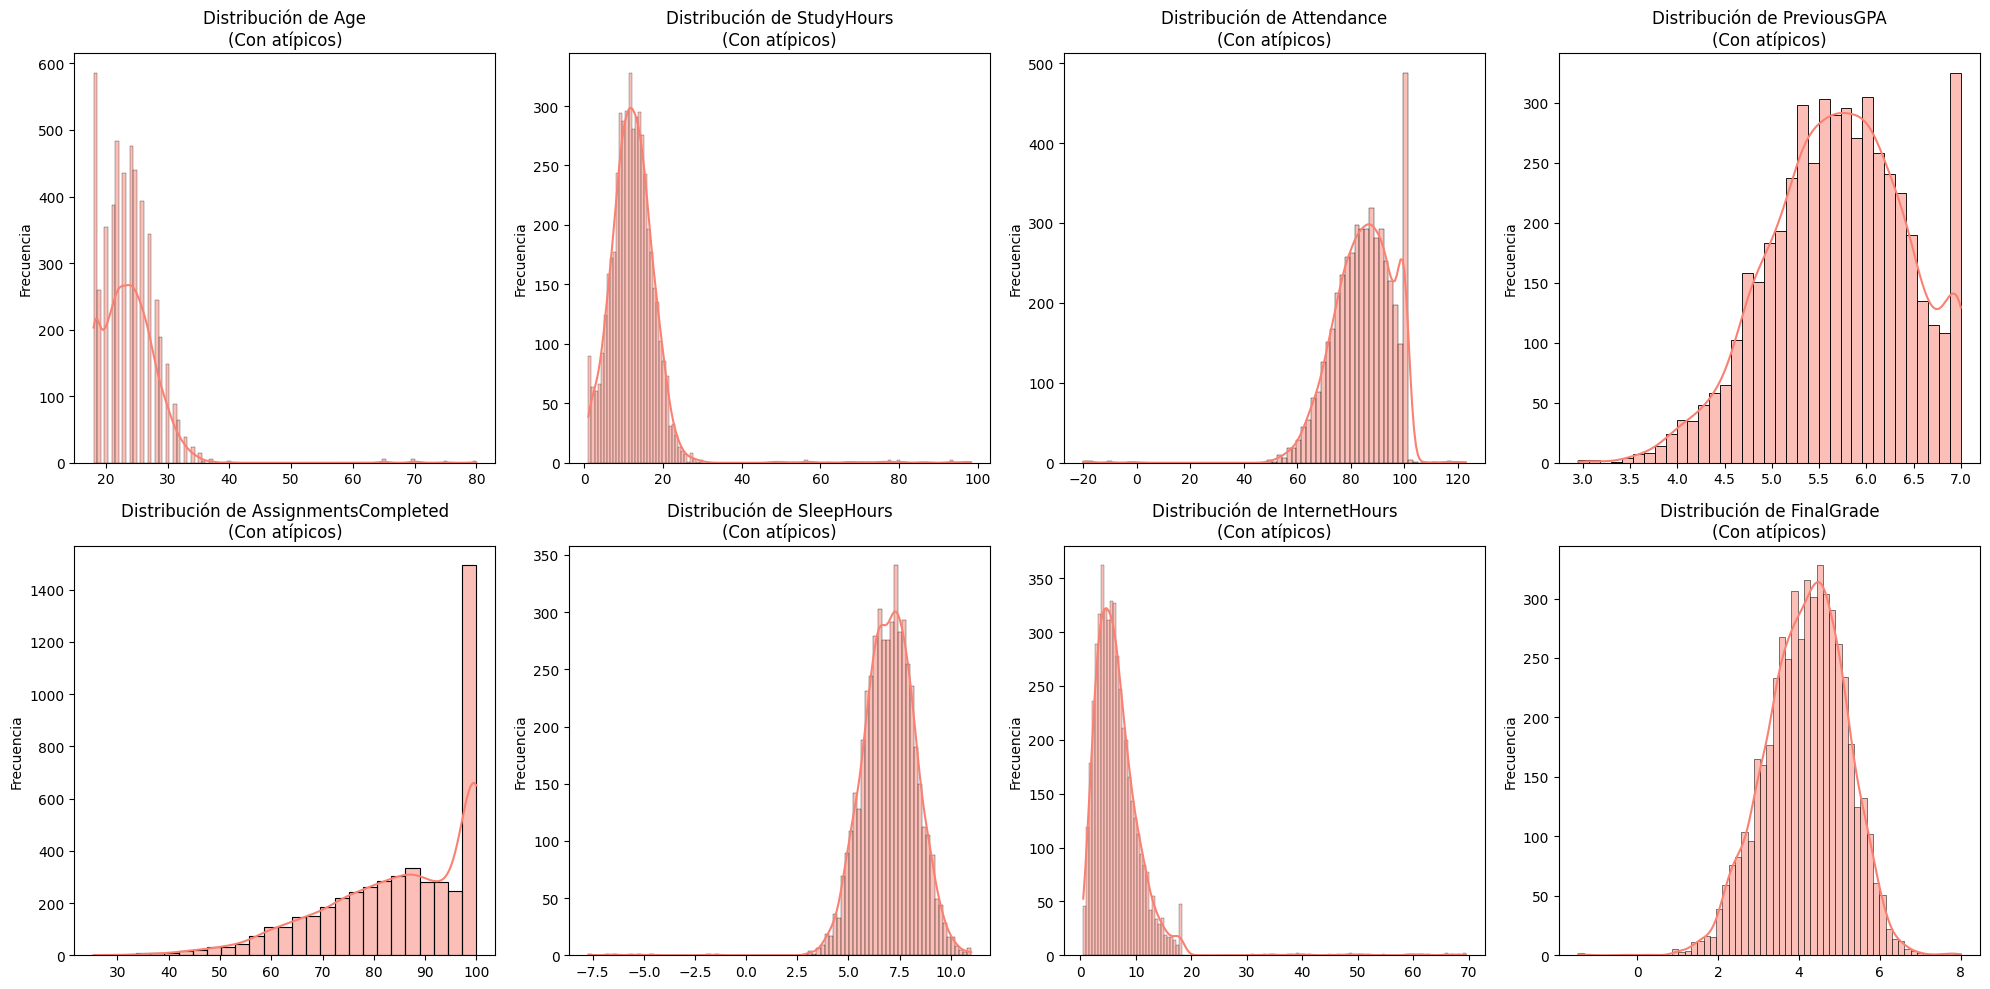

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='salmon')
    axes[i].set_title(f'Distribución de {col}\n(Con atípicos)', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Interpretación:** En estos graficos donde se puede observar la distribución de los datos de las variables numericas. Podemos ver como afectan al analisis los valores atípicos e incosistentes, como por ejemplo en la distribución de las notas finales, teniendo valores que se encuentran fuera de los limites (1 al 7) o en la distribución de las horas de sueño, donde hay valores negativos, cosa que es imposible.

### 2.2 Análisis de Variables Categóricas

Revisamos cómo se distribuyen los estudiantes en los diferentes programas académicos y la proporción de estudiantes becados.

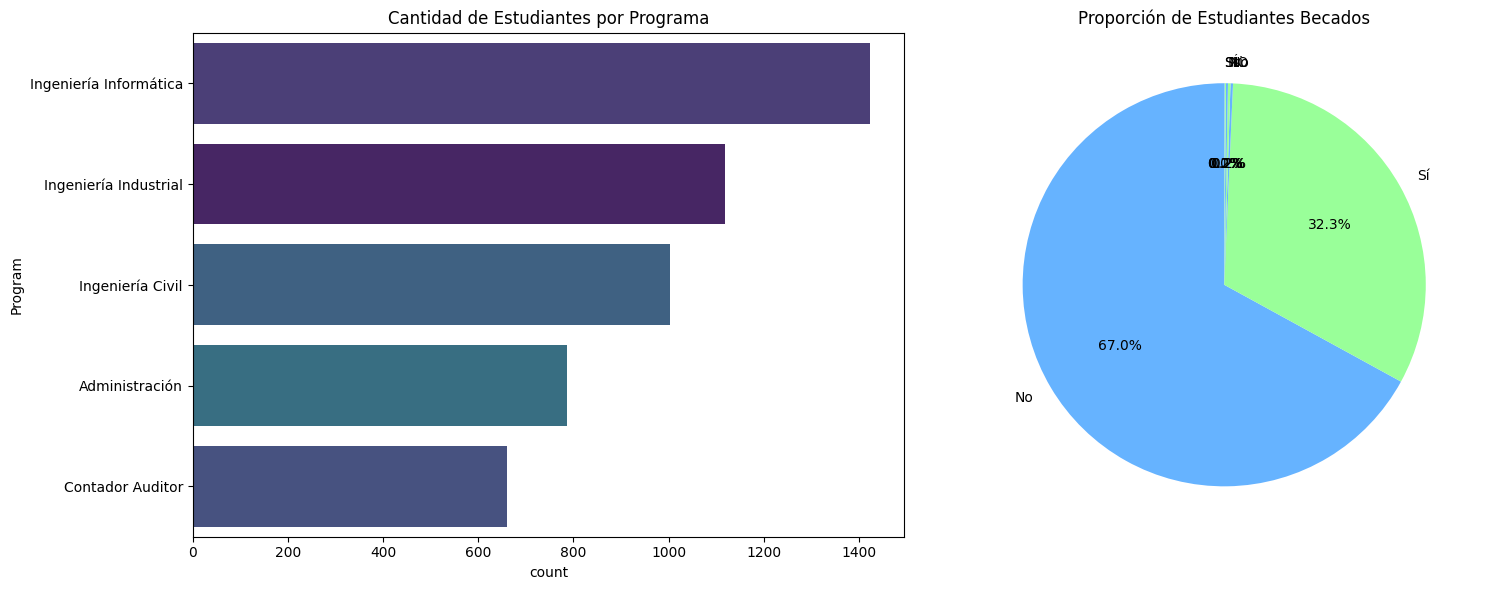

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución por Programa
sns.countplot(data=df, y='Program', hue='Program', ax=axes[0], palette='viridis', order=df_clean['Program'].value_counts().index, legend=False)
axes[0].set_title('Cantidad de Estudiantes por Programa')

# Distribución de Becas
df['Scholarship'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#66b3ff','#99ff99'], startangle=90)
axes[1].set_title('Proporción de Estudiantes Becados')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretación:** Observamos si la muestra está balanceada entre carreras o si hay una predominancia de algún programa, en este caso se puede ver como Ingeniería Informática es el programa que más estudiantes tiene.

Por otro lado, tambien podemos ver la proporción de estudiantes que cuentan con becas, donde se puede observar que la mayoria de estudiantes no son estudiantes becados.

### 2.3 Análisis de la Variable Objetivo: `FinalGrade`

Comenzamos analizando la distribución de las notas finales para entender el rendimiento general del grupo.

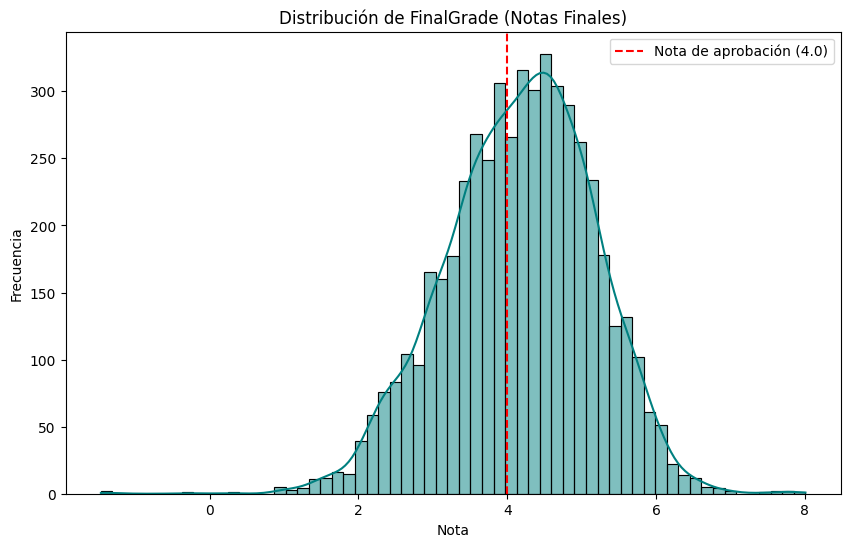

Promedio general: 4.17
Mediana general: 4.23
Porcentaje de reprobación (Nota < 4.0): 41.49%


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FinalGrade'].dropna(), kde=True, color='teal')
plt.axvline(4.0, color='red', linestyle='--', label='Nota de aprobación (4.0)')
plt.title('Distribución de FinalGrade (Notas Finales)')
plt.xlabel('Nota')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

print(f"Promedio general: {df['FinalGrade'].mean():.2f}")
print(f"Mediana general: {df['FinalGrade'].median():.2f}")
print(f"Porcentaje de reprobación (Nota < 4.0): {(df['FinalGrade'] < 4).mean()*100:.2f}%")

**Interpretación:** En el grafico podemos ver como el promedio de todos los valores dados en la variable de FinalGrade, es de 4.17, y la mediana general es de 4.23, por lo que se puede decir que en promedio los estudiantes tienen notas aprobatorias. Tambien obtiene el dato de que el 41,49% de todos los estudiantes de la Dataset reprobaron el programa al que estaban inscritos.

Por otro lado se puede ver tambien en el grafico como los valores invalidos estan graficados, por lo que estos porcentajes y valores pueden verse afectados al momento de tratar estos valores.

### 2.4 Análisis de Relaciones Relevantes

En esta sección investigamos cómo interactúan las variables entre sí y cuáles tienen mayor peso sobre el éxito académico (`FinalGrade`).

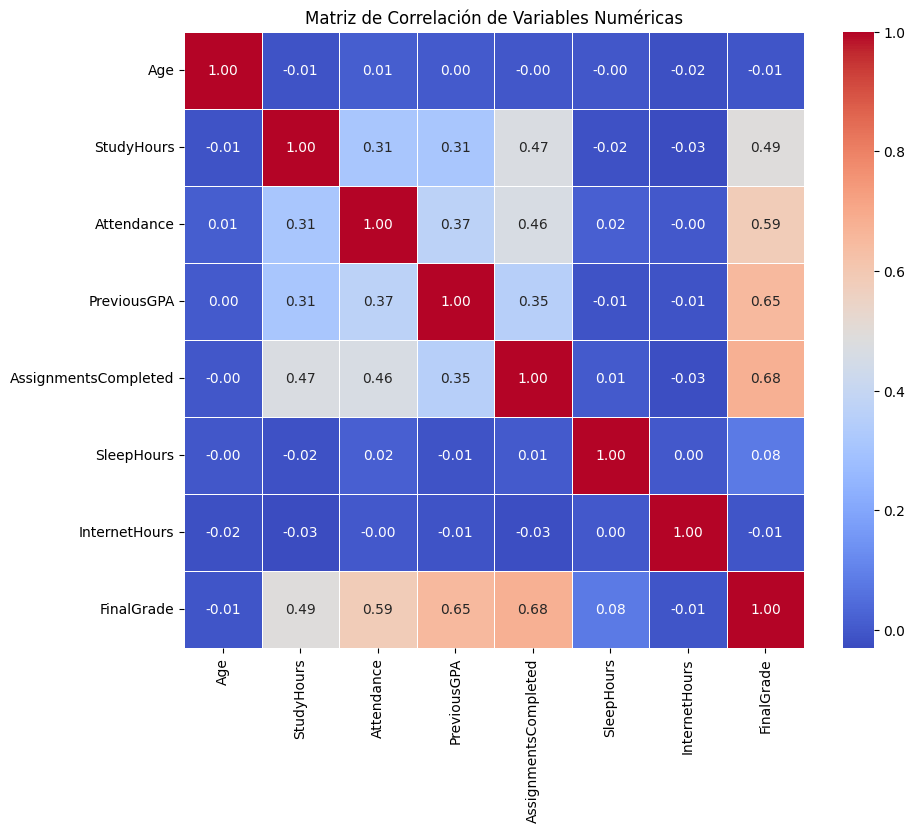

In [ ]:
# 1. Matriz de Correlación para variables numéricas
plt.figure(figsize=(10, 8))
corr_matrix = df[variables_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Interpretación:** La matriz permite identificar qué factores tienen una correlación positiva o negativa donde los valores cercanos a 1 o -1 indican relaciones fuertes. En este caso se puede ver como la nota final tiene una correlación con Attendance, PreviousGPA y AssigmentsCompleted.

Igualemente, estos valores se obtienen de la Dataset sin tratar aun los valores Atípicos y las incosistencias, por lo que podria llegar a alterar alguno de estos valores. Como por ejemplo la poca correlación con las horas de estudio o con la asistencia.

### 2.5 Relación entre características y Rendimiento Académico

Analizaremos cómo varían las notas según el programa académico y si tener beca influye en el resultado.

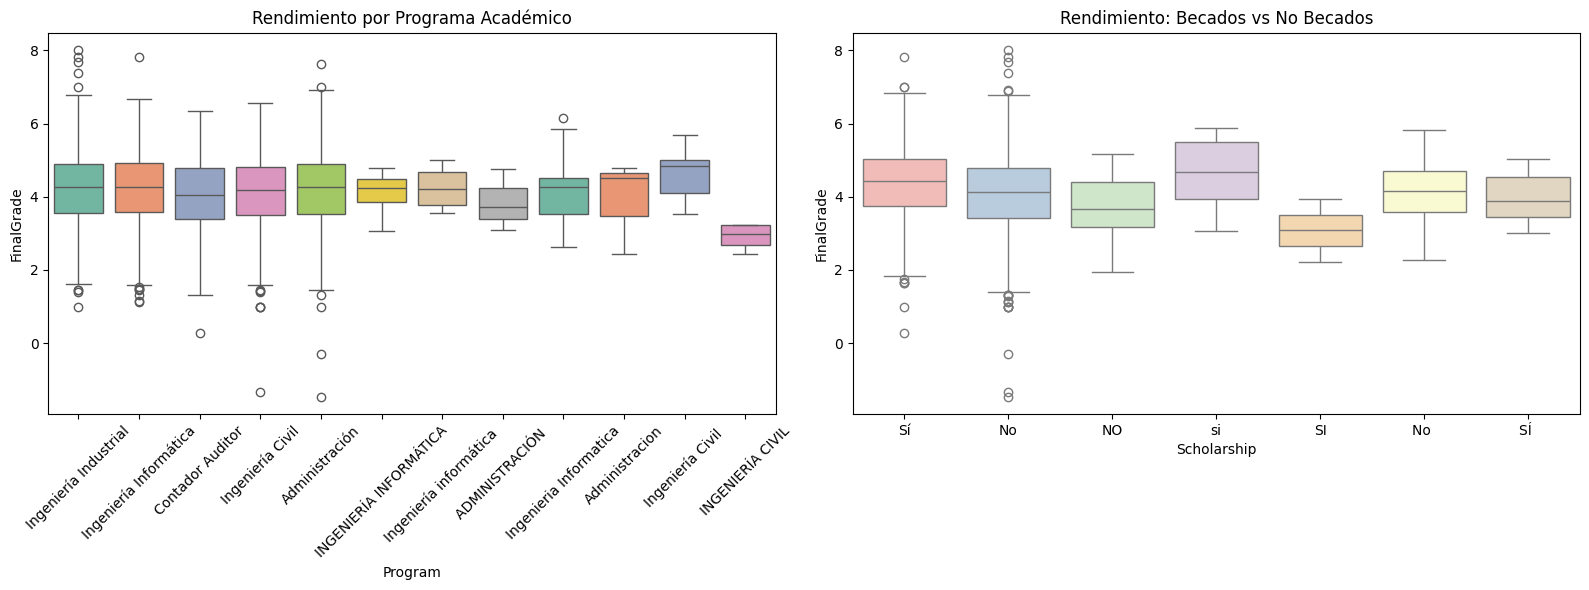

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por Programa
sns.boxplot(x='Program', y='FinalGrade', data=df, ax=axes[0], hue='Program', palette='Set2', legend=False)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Rendimiento por Programa Académico')

# Boxplot por Beca
sns.boxplot(x='Scholarship', y='FinalGrade', data=df, ax=axes[1], hue='Scholarship', palette='Pastel1', legend=False)
axes[1].set_title('Rendimiento: Becados vs No Becados')

plt.tight_layout()
plt.show()

**Interpretación:** Estas visualizaciones permiten identificar si hay programas con rendimientos significativamente distintos o si la beca actúa como un factor diferenciador en el éxito académico. Y se puede ver que no necesariamente un programa tiene mejor aprobación que otras y que los estudiantes becados si tienen a tener mejor nota final, o porlomenos la gran mayoria. Aunque se puede obtener un mejor analisis luego de normalizar las incosistencias en las respuestas de los becados, dejando unicamente dos diagramas de cajas.

##2.6 Relación entre Horas de Estudio vs FinalGrade y Edad vs FinalGrade

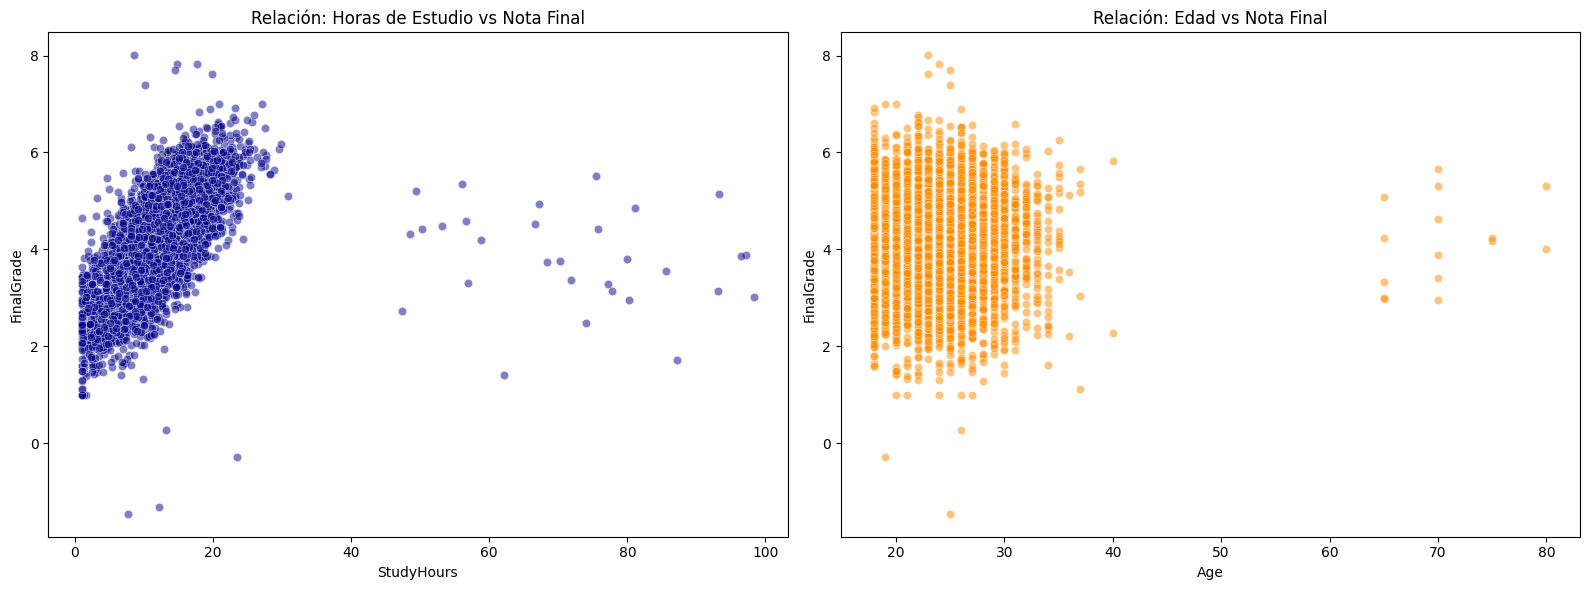

In [ ]:
# 2. Relaciones específicas con la Nota Final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horas de Estudio vs FinalGrade
sns.scatterplot(data=df, x='StudyHours', y='FinalGrade', alpha=0.5, ax=axes[0], color='darkblue')
axes[0].set_title('Relación: Horas de Estudio vs Nota Final')

# Edad vs FinalGrade
sns.scatterplot(data=df, x='Age', y='FinalGrade', alpha=0.5, ax=axes[1], color='darkorange')
axes[1].set_title('Relación: Edad vs Nota Final')

plt.tight_layout()
plt.show()

**Interpretación:**
- El gráfico de **Horas de Estudio** nos permite ver si a mayor esfuerzo académico existe una mejora lineal en las notas. Sin embargo debido a los valores atípicos e incosistentes que no han sido limpiados alteran en gran medida a la distribución de los puntos en el grafico.

- El gráfico de **Edad** ayuda a determinar si el rendimiento es consistente a lo largo de la vida del estudiante o si hay grupos etarios con mayor riesgo académico. Al igual que con el grafico anterior los valores que no han sido limpiados afectan a la distribución de los puntos en el grafico, impidiendo tener un analisis limpio, aunque se puede observar como los estudiantes mayores de edad tienden a rondar en notas más cercanas al 4.

## 2.7 Relación Asistencia vs. Rendimiento Académico

Finalmente, exploramos una de las relaciones que la matriz de correlación sugirió como más fuerte: el impacto de asistir a clases en la nota final.

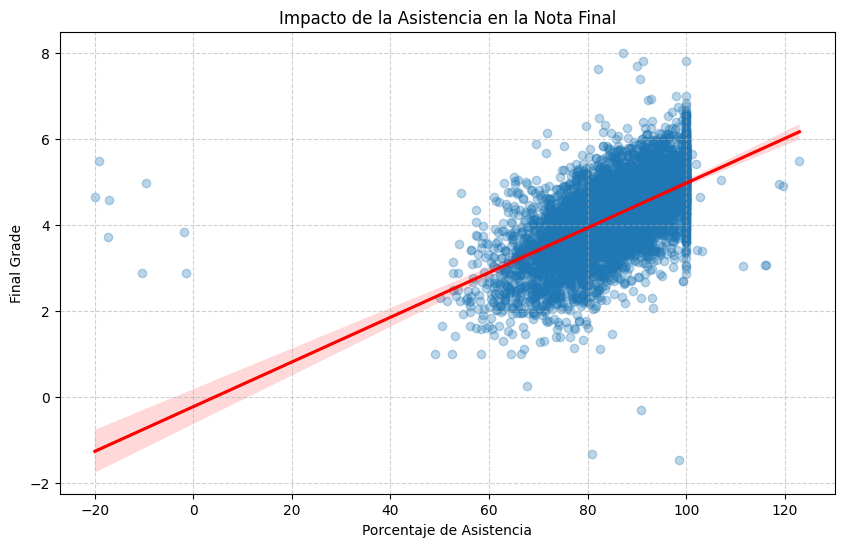

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Attendance', y='FinalGrade', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impacto de la Asistencia en la Nota Final')
plt.xlabel('Porcentaje de Asistencia')
plt.ylabel('Final Grade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Interpretación:** El gráfico de dispersión con línea de regresión confirma la tendencia: a mayor asistencia, mejores son las notas finales. Y observando el grafico se puede determinar que un mayor porcentaje de asistencia si impacta en la nota final, donde mientras mayor asistencia tenga un estudiante pueden llegar a tener una mejor nota final.

De igual manera en este grafico se puede ver como afecta los valores atípicos que no han sido limpiados aun del Dataset influenciando en el analisis del grafico.

# 3. Tratamiento de Datos

En esta sección aplicamos las correcciones necesarias basadas en el diagnóstico de calidad realizado en el punto 1. El objetivo es obtener un dataset limpio (`df_clean`) apto para análisis posteriores.
```

In [ ]:
# Creamos una copia para el proceso de limpieza
df_clean = df.copy()

# --- 3.1 Tratamiento de Registros Duplicados ---

df_clean = df_clean.drop_duplicates()
print(f"Registros después de eliminar duplicados: {df_clean.shape[0]}")

Registros después de eliminar duplicados: 5000


1.  **Eliminación de Duplicados**: Se removieron 100 filas redundantes .

---


Justificación: Se detectaron 100 registros con StudentID y datos idénticos.
Estos no aportan información nueva y pueden sesgar el análisis.

In [ ]:
# --- 3.2 Tratamiento de Inconsistencias (Fuera de Dominio) ---

for col, (lo, hi) in dominios.items():
    mask_inconsistente = (df_clean[col] < lo) | (df_clean[col] > hi)
    df_clean.loc[mask_inconsistente, col] = np.nan


2.  **Limpieza de Dominios**: Variables como `FinalGrade` y `Attendance` ahora solo contienen valores dentro del rango legal chileno y porcentual respectivamente.

---
Justificación: Valores como horas negativas o notas > 7 son errores de captura.
Los convertimos a NaN para tratarlos como faltantes y no distorsionar estadísticas.


In [ ]:
# --- 3.3 Estandarización de Variables Categóricas ---
# Justificación: Corregimos variaciones de formato (mayúsculas, tildes, espacios).
def corregir_categoria(val, oficiales_dict):
    key = normalizar(val)
    return oficiales_dict.get(key, val)

for col, oficiales in categorias_oficiales.items():
    df_clean[col] = df_clean[col].apply(lambda x: corregir_categoria(x, oficiales))

3.  **Estandarización**: `Scholarship` y `Program` ahora tienen categorías únicas y limpias.

In [ ]:
# 3.4 Validación de atipicos
# Comprobamos que el Mínimo y Máximo de cada variable esté dentro del rango permitido.
verificacion_lista = []
for col, (lo, hi) in dominios.items():
    min_act = df_clean[col].min()
    max_act = df_clean[col].max()
    # Contamos si quedó algo fuera (debería ser 0)
    n_fuera = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()

    verificacion_lista.append({
        "Variable": col,
        "Dominio Esperado": f"[{lo}, {hi}]",
        "Mín Actual": round(min_act, 2),
        "Máx Actual": round(max_act, 2),
        "Anomalías Restantes": n_fuera
    })

df_verif_num = pd.DataFrame(verificacion_lista)
print("TABLA DE CONTROL: VERIFICACIÓN DE LÍMITES LÓGICOS")
display(df_verif_num)

# 2. Validación de Estandarización Categórica
print("\nVERIFICACIÓN DE CATEGORÍAS ESTANDARIZADAS:")
for col in categorias_oficiales.keys():
    print(f"- {col}: {df_clean[col].unique().tolist()}")

TABLA DE CONTROL: VERIFICACIÓN DE LÍMITES LÓGICOS


,Variable,Dominio Esperado,Mín Actual,Máx Actual,Anomalías Restantes
0,Age,"[0, 100]",18.00,80.00,0
1,Attendance,"[0, 100]",49.01,100.00,0
2,AssignmentsCompleted,"[0, 100]",25.34,100.00,0
3,PreviousGPA,"[1.0, 7.0]",2.95,7.00,0
4,SleepHours,"[0, 24]",3.00,11.00,0
5,InternetHours,"[0, 24]",0.50,18.00,0
6,StudyHours,"[0, 24]",1.00,23.92,0
7,FinalGrade,"[1.0, 7.0]",1.00,7.00,0



VERIFICACIÓN DE CATEGORÍAS ESTANDARIZADAS:
- Scholarship: ['Sí', 'No']
- Program: ['Ingeniería Industrial', 'Ingeniería Informática', 'Contador Auditor', 'Ingeniería Civil', 'Administración']


#atipicos


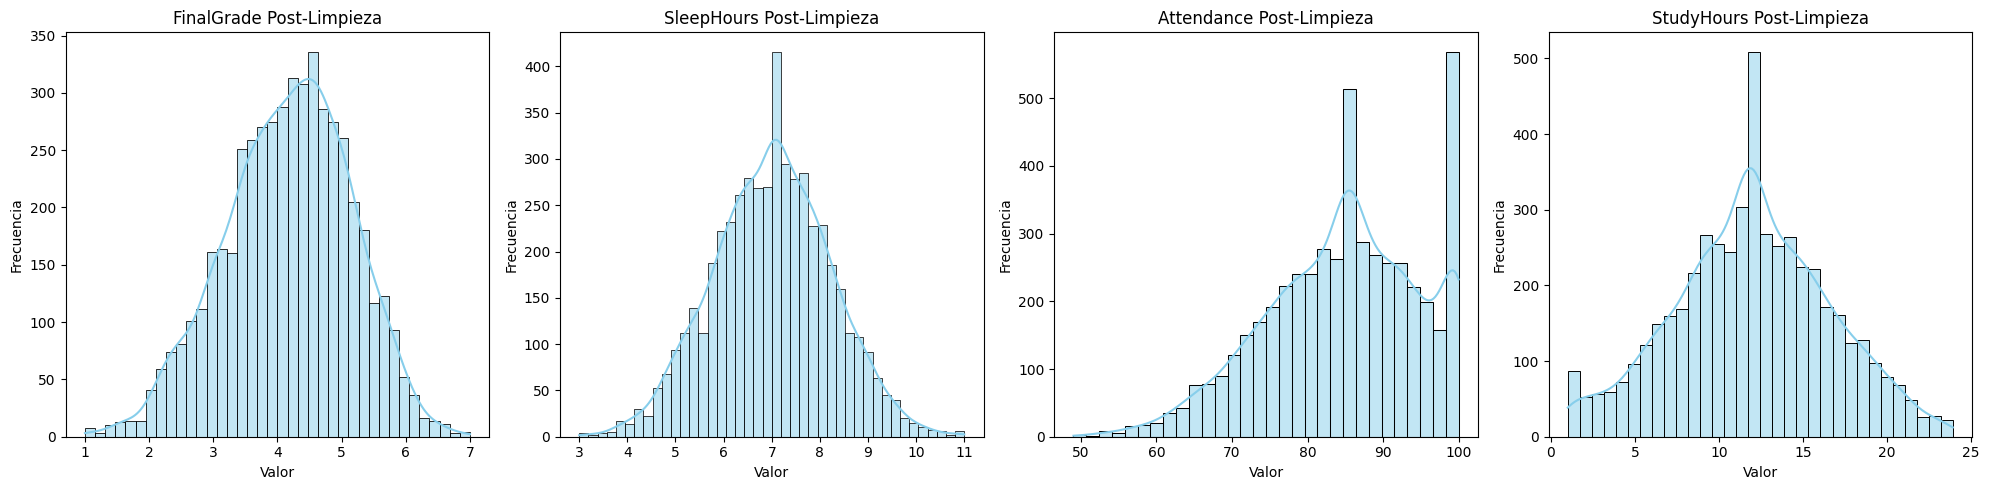

In [ ]:
# 3. Visualización de Distribución Limpia
# Comparamos visualmente las variables críticas para confirmar la ausencia de outliers inválidos.
vars_criticas = ['FinalGrade', 'SleepHours', 'Attendance', 'StudyHours']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(vars_criticas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Post-Limpieza')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# --- 3.4 Imputación de Valores Faltantes ---

# A) Variables Numéricas

for index, row in tabla_num.iterrows():
    col = row['Variable']
    estrategia = row['Estrategia de imputación']

    if estrategia == 'Media':
        valor_imputacion = df_clean[col].mean()
    else:
        valor_imputacion = df_clean[col].median()

    df_clean[col] = df_clean[col].fillna(valor_imputacion)

# B) Variables Categóricas
for col in cat_con_na:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

print("Imputación completada.")
# Verificación final
print(f"Valores faltantes totales: {df_clean.isnull().sum().sum()}")
display(df_clean.head())

Imputación completada.
Valores faltantes totales: 10


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


4.  **Imputación Robusta**: Se preservó la tendencia central de los datos sin dejar valores nulos, respetando la naturaleza de cada distribución (simétrica vs asimétrica).

---
Justificación: Usamos Media para PreviousGPA (distribución normal) y Mediana para el resto (presencia de outliers/asimetría o 'Efecto Bill Gates').
Justificación: Imputamos con la Moda al ser variables cualitativas.


In [ ]:
print('Valores faltantes después de la primera imputación:')
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_frame('n_faltantes'))


Valores faltantes después de la primera imputación:


,n_faltantes
FinalGrade,10


In [ ]:
# 3.5 Imputación final de FinalGrade
# Imputamos los 10 NaN generados al limpiar inconsistencias en el punto 3.2
final_grade_median = df_clean['FinalGrade'].median()
df_clean['FinalGrade'] = df_clean['FinalGrade'].fillna(final_grade_median)

print(f"Imputación manual de FinalGrade completada con mediana: {final_grade_median:.2f}")
print(f"Total de valores nulos en df_clean: {df_clean.isnull().sum().sum()}")

Imputación manual de FinalGrade completada con mediana: 4.23
Total de valores nulos en df_clean: 0



Con esto, el dataset `df_clean` está totalmente libre de duplicados, inconsistencias y valores faltantes, respetando las distribuciones originales mediante una limpieza controlada paso a paso.

### 3.6 Visualización del Dataset Final Limpio

En esta sección validamos gráficamente que el tratamiento de datos fue exitoso.

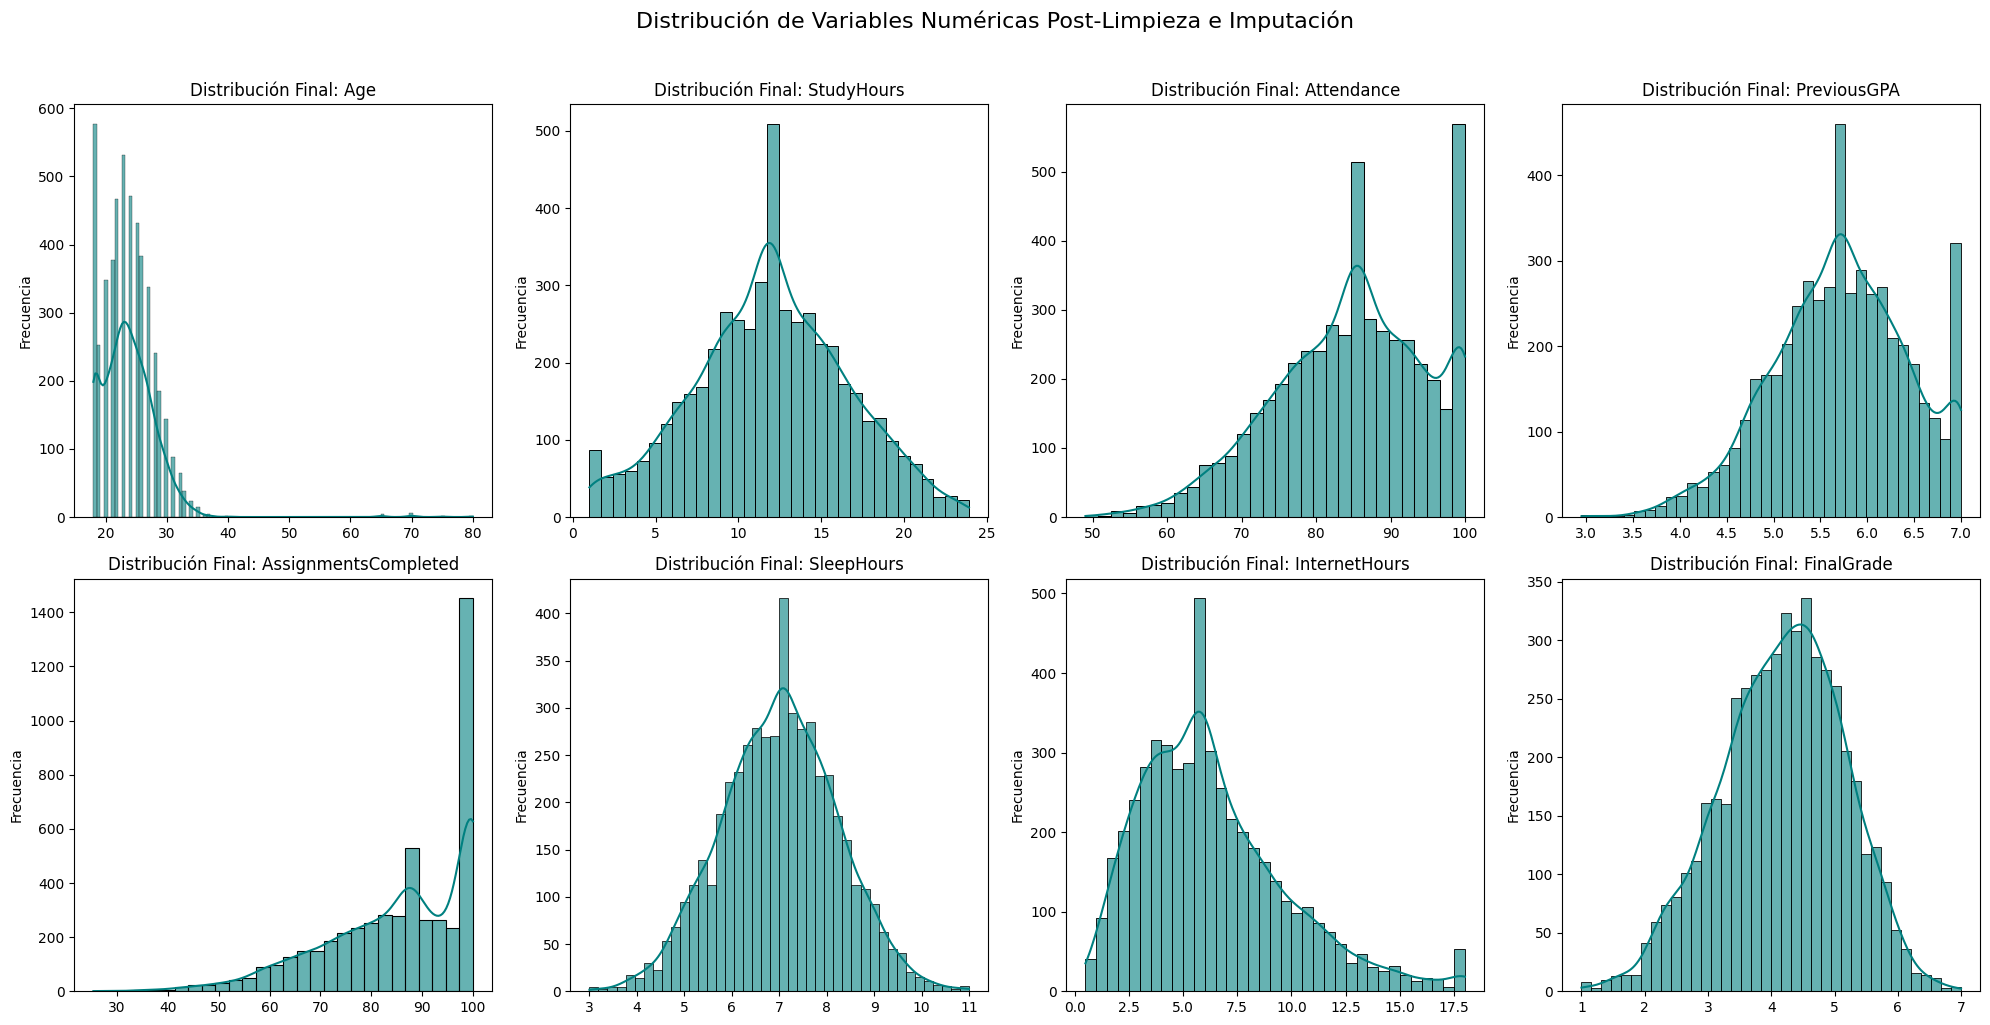

In [ ]:
# 1. Histogramas de Distribución Final
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='teal', alpha=0.6)
    axes[i].set_title(f'Distribución Final: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Post-Limpieza e Imputación', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

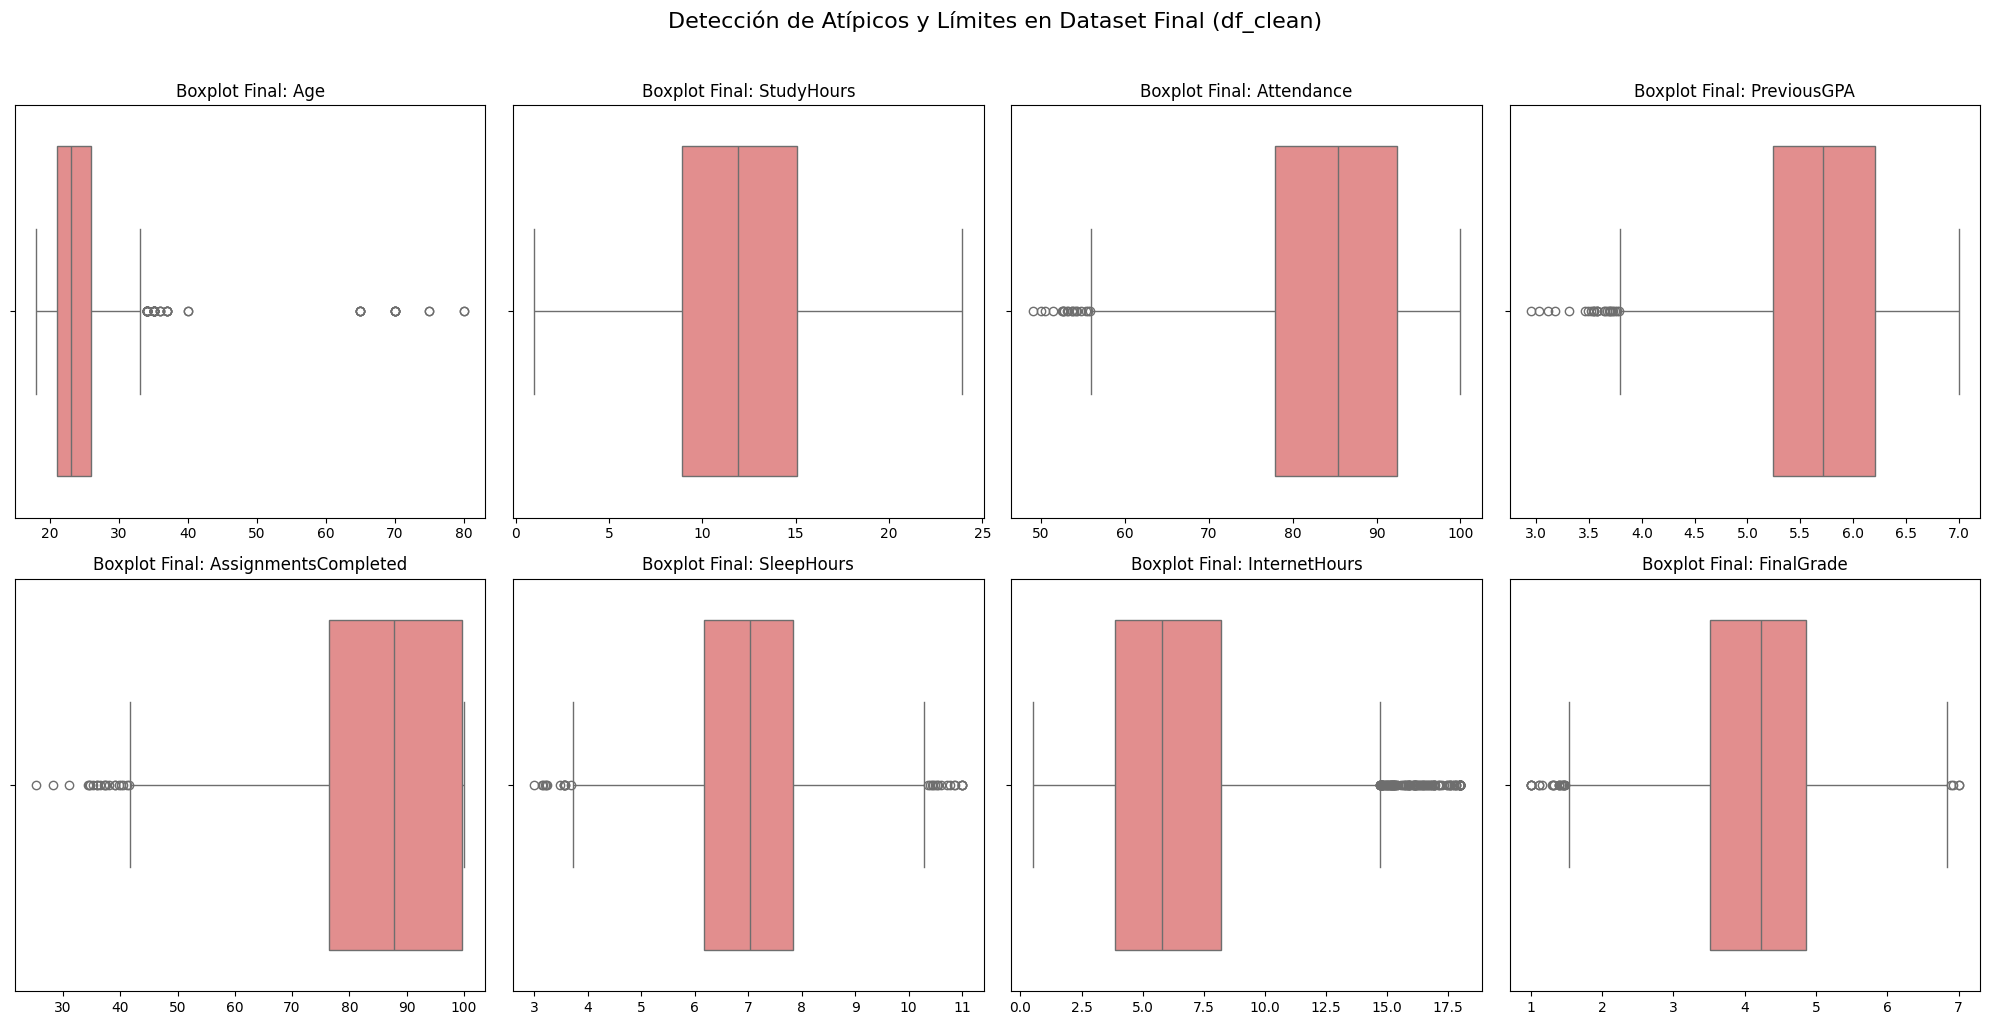

In [ ]:
# 2. Boxplots para validación de límites
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot Final: {col}')
    axes[i].set_xlabel('')

plt.suptitle('Detección de Atípicos y Límites en Dataset Final (df_clean)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()